In [2]:
#from jax import random as random
from pennylane import numpy as np
import pennylane as qml

import pandas as pd
import matplotlib.pyplot as plt

<h1> <center> Toy Example of VQE: Finding energy spectrum of Hamiltonian </center> <h1>

## 1. Tight-binding Hamiltonian $\hat{H}_{TB}$

$$
\hat{H}_{TB} = \sum_{i',i} |i'\rangle\langle i|
$$

In [5]:
H = np.genfromtxt('hamiltonian_matrix.dat')
H

tensor([[-13.01,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.1 ,   0.7 ,   0.  ,   0.  ],
        [  0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.19,  -3.65,   0.  ,   0.  ],
        [  0.  ,   0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55,   0.  ],
        [  0.  ,   0.  ,   0.  ,  -1.96,   0.  ,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55],
        [  0.  ,   0.  ,   0.  ,   0.  , -13.01,   0.  ,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.1 ,   0.  ,   0.7 ,   0.  ],
        [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,  -1.96,   0.  ,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.55,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,  -1.96,   0.  ,
           0.  ,   0.  ,   0.  ,   0.  ,  -1.

In [6]:
size_H = H.shape[0]
n_qubits = np.log2(size_H).astype(int)
print('# of qubits:', n_qubits)

# of qubits: 4


In [7]:
H_spectrum = np.linalg.eigvalsh(H)
H_spectrum

tensor([-13.83497342, -13.04468236, -13.04468236,  -8.93763366,
         -4.10326094,  -4.10326094,  -3.48761854,  -1.96      ,
         -1.96      ,  -1.96      ,  -1.96      ,  -1.96      ,
         -1.92572286,   4.5179433 ,   4.5179433 ,   4.58594848], requires_grad=True)

<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/var/folders/rg/1x1dtgp53p7_51yck_2xq2qh0000gn/T/ipykernel_16530/3024832823.py:2: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Energy Spectrum of $ \hat{H} $")


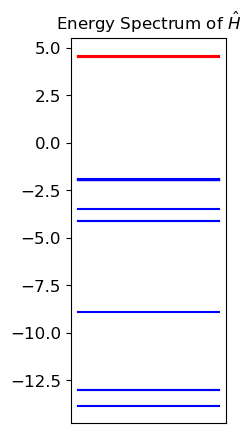

In [9]:
plt.figure(figsize=(2,5))
plt.title("Energy Spectrum of $ \hat{H} $")
plt.xticks(ticks=[])
plt.yticks(fontsize=12)

for y in H_spectrum:
    c = 'blue' if y<0 else 'red'
    plt.plot([0,1], [y]*2, color=c)

## 2. Variational Quantum Eigensolver (VQE)

### 2-1. Ansatz

#### 2-1-1. SU(4) Circuit

In [6]:
def su4(params, wires):
    # Reference 
    # Two-qubit SU(4) gates designed by
    # 1. Farrokh Vatan and Colin Williams, Phys. Rev. A 69, 032315 (2004)
    # 2. V. V. Shende et al., PRA 69 062321 (2004)

    if len(params) != 15:
        print(len(params))
        raise ValueError('len(params) != 15')
    if len(wires) != 2:
        raise ValueError('len(wires) != 2')
    
    qml.Rot(params[0], params[1], params[2], wires=wires[0])
    qml.Rot(params[3], params[4], params[5], wires=wires[1])

    qml.CNOT(wires=[wires[1], wires[0]])

    qml.RZ(params[6], wires=wires[0])
    qml.RY(params[7], wires=wires[1])

    qml.CNOT(wires=[wires[0], wires[1]])

    qml.RY(params[8], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])

    qml.Rot(params[9], params[10], params[11], wires=wires[0])
    qml.Rot(params[12], params[13], params[14], wires=wires[1])

Circuit Diagram

(<Figure size 1000x300 with 1 Axes>, <Axes: >)

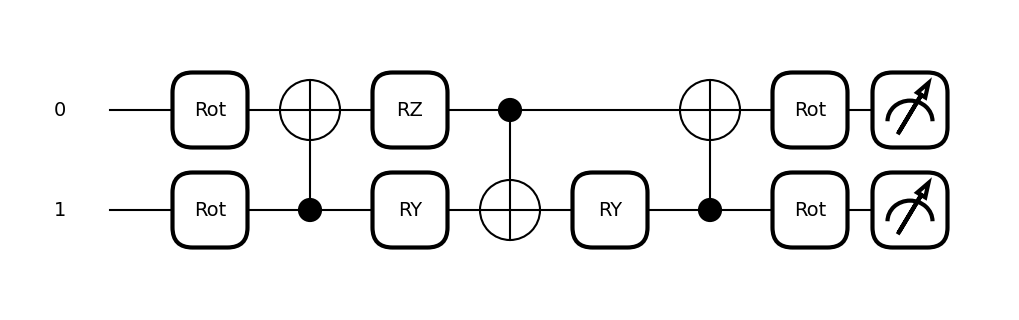

In [7]:
dev = qml.device('default.qubit', wires=2)
@qml.qnode(dev)
def circuit(params): 
    su4(params, wires=[0,1])
    return qml.expval(qml.PauliZ(0)@qml.PauliZ(1))

initial_params = np.empty((15))
qml.draw_mpl(circuit)(initial_params)

#### 2-1-2. SU(4)-based Quantum Circuit in Brickwall Pattern

In [8]:
class Brickwall:
    num_params = '(n_qubits//2, n_layers, 15)' 

    def __init__(self, params, wires:list, n_layers:int, edge_wires='open'):
        self.params, self.wires = params, wires
        self.n_layers = n_layers
        self.n_qubits = len(wires)

        #self._sanity_test()

        for lth in range(n_layers):
            self.su4_layer(lth)

    def _sanity_test(self):
        if self.params.shape[0] != self.n_layers: 
            raise ValueError('params.shape[0] != layers')
        if self.n_qubits % 2 == 0 and self.params.shape[1] != 15*self.n_layers*(self.n_qubits//2) - self.n_layers//2:
            raise ValueError('params.shape[1] != 15 * n_layers * (n_qubits//2) - n_layers//2')
        if self.n_qubits % 2 == 1 and self.params.shape[1] != 15*self.n_layers*(self.n_qubits//2):
            raise ValueError('params.shape[1] != 15 * n_layers * (n_qubits//2)')
        
    def su4_layer(self, lth:int):

        for i in range(self.n_qubits//2):
            if lth % 2 == 0:
                su4(self.params[i, lth], wires=[self.wires[2*i],self.wires[2*i+1]])        
            else:
                if self.n_qubits%2 == 0 and i == self.n_qubits//2 - 1:
                    #print(i, lth)
                    #self.params[i, lth] = np.zeros(15)
                    self.params[i, lth]
                else:
                    su4(self.params[i, lth], wires=[self.wires[2*i+1],self.wires[2*i+2]])

Circuit Diagram

(4, 6, 15)


(<Figure size 4500x900 with 1 Axes>, <Axes: >)

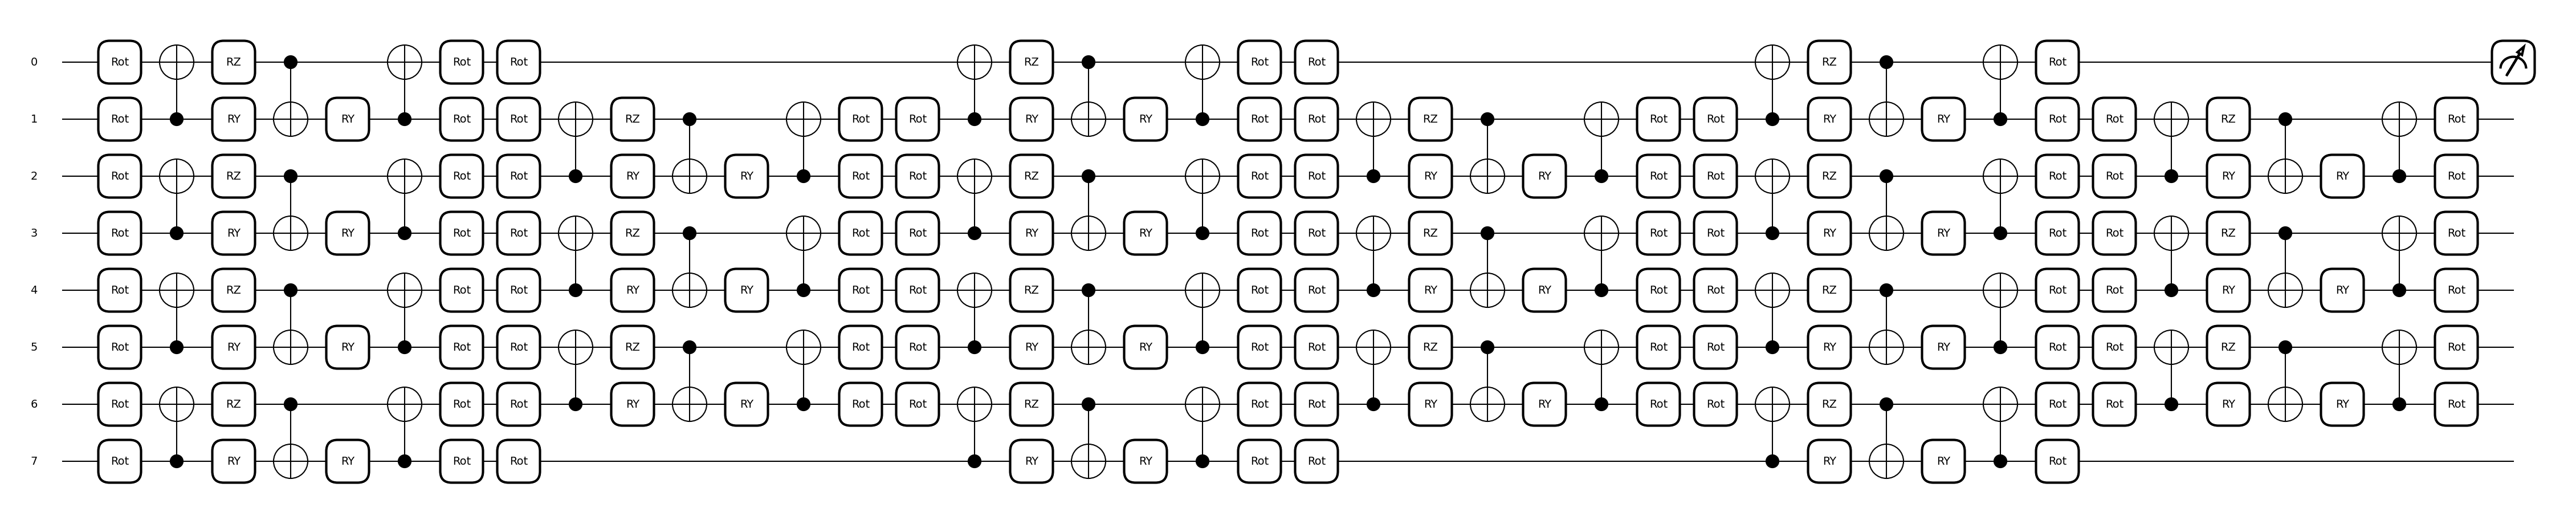

In [9]:
n_qubits, n_layers = 4, 4
n_qubits, n_layers = 8, 6
num_params = (n_qubits//2, n_layers, 15)

dev = qml.device('default.qubit', wires=n_qubits)
@qml.qnode(dev)
def circuit(params): 
    Brickwall(params, range(n_qubits), n_layers)
    return qml.expval(qml.PauliZ(0))


print(num_params)
initial_params = np.ones(num_params)
qml.draw_mpl(circuit)(initial_params)

### 2-2. Cost function

#### $\langle\psi(\boldsymbol{\theta})|\hat{H}|\psi(\boldsymbol{\theta})\rangle$

In [10]:
H_qml = qml.pauli_decompose(H)

def expval_of_H(params):
    Brickwall(params, range(n_qubits), n_layers)
    return qml.expval(H_qml)

In [11]:
dev = qml.device("default.qubit", wires=n_qubits)
qnode_expvalH = qml.QNode(expval_of_H, device=dev)

### 2-3. Implementing VQE

In [12]:
n_layers = 6
print(Brickwall.num_params)
eval(Brickwall.num_params)

(n_qubits//2, n_layers, 15)


(4, 6, 15)

#### Lowest Eigenvalue
$\min_{\boldsymbol{\theta}} \langle\psi(\boldsymbol{\theta})|\hat{H}|\psi(\boldsymbol{\theta})\rangle $

In [13]:
print(f'\n> Find the lowest eigenpair of <H>')

## Initial Variational Parameters
np.random.seed(19) 
params_size = eval(Brickwall.num_params)
params = np.random.uniform(size=params_size) * 2*np.pi

params_per_step = [params]
cost_per_step = [qnode_expvalH(params)]

## Setting Parameters
max_iterations = 1000
step_size = 0.05
conv_tol = 1e-6

## Classical Optimizer: Gradient Descent
opt = qml.GradientDescentOptimizer(stepsize=step_size)

for n in range(max_iterations):
    # Optimization
    params, prev_energy = opt.step_and_cost(qnode_expvalH, params)
    cost_per_step.append(qnode_expvalH(params))
    params_per_step.append(params)

    # Convergence
    #conv = np.abs(cost_per_step[-1] - prev_energy) / np.abs(cost_per_step[-1])
    conv = np.abs(cost_per_step[-1] - prev_energy)

    if n % 50 == 0:
        print(f"  Step = {n},  Cost = {cost_per_step[-1]:.8f}")
        #print("  params:", params_per_step[-1])

    if n == max_iterations-1 or conv <= conv_tol:
        
        print('Total Iterations:', n, end=', ')
        print(f'Cost : {cost_per_step[-1]:.8f}', end=', ')
        print(f'Exact : {H_spectrum[0]:.8f}', end=', ')
        #print(f'Square Root of Cost : {np.sqrt(cost_per_step[-1]):.8f}')
        #self.results['eigen_energies'].append(self.cost_expval_H(params_per_step[-1]))
        #print(f"Eigenenergy : {self.results['eigen_energies'][-1]:.8f}")
        
        break



> Find the lowest eigenpair of <H>
  Step = 0,  Cost = -6.09177440
  Step = 50,  Cost = -13.18007470
  Step = 100,  Cost = -13.64771040
  Step = 150,  Cost = -13.60129976
  Step = 200,  Cost = -13.62594591
  Step = 250,  Cost = -13.73880806
  Step = 300,  Cost = -13.77328649
  Step = 350,  Cost = -13.70009178
  Step = 400,  Cost = -13.74594624
  Step = 450,  Cost = -13.75563143
  Step = 500,  Cost = -13.76586625
  Step = 550,  Cost = -13.74967390
  Step = 600,  Cost = -13.71250045
  Step = 650,  Cost = -13.73121776
  Step = 700,  Cost = -13.78387441
  Step = 750,  Cost = -13.74775173
  Step = 800,  Cost = -13.74201361
  Step = 850,  Cost = -13.81318948
  Step = 900,  Cost = -13.70701404
  Step = 950,  Cost = -13.76393330
Total Iterations: 999, Cost : -13.81435726, Exact : -13.83497342, 

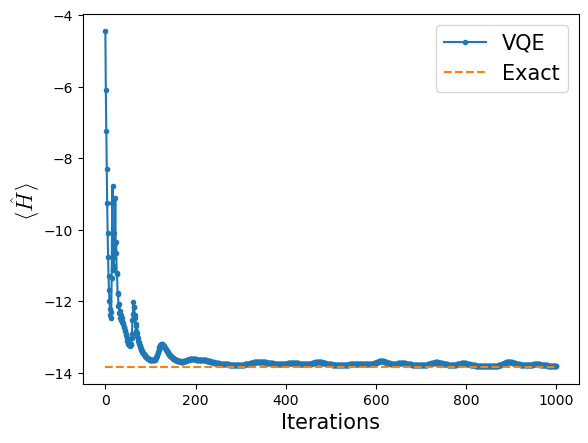

In [14]:
plt.plot(range(len(cost_per_step)), cost_per_step, '.-', label='VQE')
plt.plot(range(len(cost_per_step)), [H_spectrum[0]]*len(cost_per_step), '--', label='Exact')
#plt.title('Tight-Binding Hamiltonian Simulation', fontsize=15)
plt.ylabel(r'$\langle \hat{H} \rangle$', usetex=True, fontsize=17)
plt.xlabel('Iterations', fontsize=15)
plt.legend(fontsize=15)
plt.show()

---
---

## 3. Partitioning a Hamiltonian in the Pauli Basis

### 3-1. Pauli Decomposition

Expressing Hamiltonian as a linear combination of Pauli strings:

In [34]:
qml.pauli_decompose(H)

<Hamiltonian: terms=64, wires=[0, 1, 2, 3]>


In [17]:
H_qml = qml.pauli_decompose(H)

Table

In [15]:
pd_data = np.array([H_qml.coeffs[:32], H_qml.ops[:32], H_qml.coeffs[32:64], H_qml.ops[32:64]]).T
pd.DataFrame(pd_data, columns=['Coefficient', 'Pauli String']*2)

,Coefficient,Pauli String,Coefficient,Pauli String
0,-3.66625,I(0) @ I(1) @ I(2) @ I(3),0.06125,X(0) @ Z(1) @ X(2) @ I(3)
1,-2.78125,I(0) @ I(1) @ I(2) @ Z(3),0.06125,X(0) @ Z(1) @ X(2) @ Z(3)
2,-2.78125,I(0) @ I(1) @ Z(2) @ I(3),-0.31875,X(0) @ Z(1) @ Z(2) @ I(3)
3,-2.78125,I(0) @ I(1) @ Z(2) @ Z(3),-0.31875,X(0) @ Z(1) @ Z(2) @ Z(3)
4,-0.45625,I(0) @ X(1) @ I(2) @ I(3),-0.23625,Y(0) @ I(1) @ Y(2) @ I(3)
5,0.31875,I(0) @ X(1) @ I(2) @ Z(3),-0.23625,Y(0) @ I(1) @ Y(2) @ Z(3)
6,-0.06125,I(0) @ X(1) @ X(2) @ X(3),-0.23625,Y(0) @ X(1) @ I(2) @ Y(3)
7,0.06125,I(0) @ X(1) @ Y(2) @ Y(3),-0.23625,Y(0) @ X(1) @ Z(2) @ Y(3)
8,0.31875,I(0) @ X(1) @ Z(2) @ I(3),0.45625,Y(0) @ Y(1) @ I(2) @ I(3)
9,-0.73125,I(0) @ X(1) @ Z(2) @ Z(3),0.06125,Y(0) @ Y(1) @ I(2) @ X(3)


### 3-2. Pauli Grouping

It is used for reducing the required number of quantum circuits when evaluating $\langle\hat{H}\rangle$ 

#### Qubit-Wise Commutativity

In [18]:
ops_groupings_qwc, coeffs_groupings_qwc = qml.pauli.group_observables(observables=H_qml.ops, coefficients=H_qml.coeffs, grouping_type='qwc')
print(len(ops_groupings_qwc))

15


##### Examples: $[X_0\otimes Y_1 \otimes I_2, \;X_0\otimes I_1 \otimes Z_2]$ 

In [16]:
obs = [
    qml.PauliX(0) @ qml.PauliY(1),
    qml.PauliX(0) @ qml.PauliZ(2)
]

In [20]:
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev, interface="jax")
def circuit1(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(3))
    return qml.expval(obs[0])


@qml.qnode(dev, interface="jax")
def circuit2(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(3))
    return qml.expval(obs[1])

param_shape = qml.templates.StronglyEntanglingLayers.shape(n_layers=3, n_wires=3)
key, scale = random.PRNGKey(192933), 0.1
weights = scale * random.normal(key, shape=param_shape)

print("Expectation value of XYI = ", circuit1(weights))
print("Expectation value of XIZ = ", circuit2(weights))

AttributeError: module 'random' has no attribute 'PRNGKey'

#### Full Commutativity

In [19]:
ops_groupings_fc, coeffs_groupings_fc = qml.pauli.group_observables(observables=H_qml.ops, coefficients=H_qml.coeffs, grouping_type='commuting')
print(len(ops_groupings_fc))

5


##### Examples

### 3-3. Results

Text(0.5, 1.0, 'Perovskite')

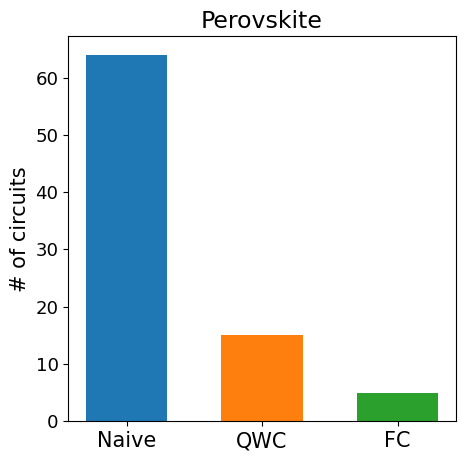

In [ ]:
xrange = [0, 0.5, 1]
barwidth = 0.3

plt.figure(figsize=(5,5))
plt.bar(xrange[0], H_qml.num_params, width=barwidth, label='Naive')
plt.bar(xrange[1], len(ops_groupings_qwc), width=barwidth, label='QWC')
plt.bar(xrange[2], len(ops_groupings_fc), width=barwidth, label='FC')

plt.xticks([0, 0.5, 1],['Naive','QWC','FC'], fontsize=15)
plt.yticks(fontsize=13)
plt.ylabel('# of circuits', fontsize=15)
plt.title('Perovskite', fontsize=17)
#plt.legend()